
---

**Dataset:** Titanic Dataset — https://www.kaggle.com/competitions/titanic/data


## Task 1: Data Acquisition

The dataset (`train.csv`) was downloaded from the Kaggle Titanic competition page and saved
in the same folder as this notebook. Below we import it into Python with **Pandas** and
inspect its basic structure.

In [1]:
# Import the libraries used throughout the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")   # consistent style for all charts
%matplotlib inline

In [2]:
# Load the dataset into a Pandas DataFrame
df = pd.read_csv("train.csv")

# Dataset dimensions (rows, columns)
print("Dataset dimensions (rows, columns):", df.shape)

Dataset dimensions (rows, columns): (891, 12)


In [3]:
# Column names
print("Column names:")
print(list(df.columns))

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Data types of each column
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Observations (Task 1):**

- The dataset contains **891 rows (passengers)** and **12 columns (variables)**.
- The columns are a mix of numerical variables (`Age`, `Fare`, `SibSp`, `Parch`,
  `PassengerId`, `Survived`, `Pclass`) and categorical/text variables
  (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`).
- `Survived` is the target variable: **1 = survived, 0 = did not survive**.
- `Pclass` (ticket class: 1st, 2nd, 3rd) is stored as an integer but is really an
  ordinal categorical variable.

## Task 2: Data Cleaning

In this section we detect missing values and duplicated observations, handle them,
and explain every preprocessing decision.

In [6]:
# Detect missing values (count and percentage per column)
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})
missing[missing["Missing Count"] > 0]

,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


**Missing-value findings:**

| Column | Missing | % | Decision |
|---|---|---|---|
| `Age` | 177 | 19.87% | **Impute with the median age (28.0 years).** The median is robust to outliers and to the right-skew of the age distribution, so it is a safer choice than the mean. Deleting ~20% of the rows would throw away too much information. |
| `Cabin` | 687 | 77.10% | **Drop the column.** With more than three-quarters of the values missing, any imputation would be mostly guesswork and the column would add noise rather than signal. |
| `Embarked` | 2 | 0.22% | **Impute with the mode ('S' — Southampton).** Only two values are missing and Southampton is by far the most common port of embarkation, so this is the most likely true value. |

In [7]:
# Handle missing values
df_clean = df.copy()

# 1. Age -> impute with the median
median_age = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(median_age)
print(f"Age imputed with median = {median_age}")

# 2. Cabin -> drop the column (77% missing)
df_clean = df_clean.drop(columns=["Cabin"])
print("Cabin column dropped")

# 3. Embarked -> impute with the mode
mode_embarked = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(mode_embarked)
print(f"Embarked imputed with mode = '{mode_embarked}'")

# Verify that no missing values remain
print("\nMissing values remaining:", df_clean.isnull().sum().sum())

Age imputed with median = 28.0
Cabin column dropped
Embarked imputed with mode = 'S'

Missing values remaining: 0


In [8]:
# Detect duplicated observations
n_duplicates = df_clean.duplicated().sum()
print("Number of duplicated rows:", n_duplicates)

# Remove duplicates if any exist
if n_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed. New shape:", df_clean.shape)
else:
    print("No duplicated rows were found, so nothing needed to be removed.")

print("Final shape of the cleaned dataset:", df_clean.shape)

Number of duplicated rows: 0
No duplicated rows were found, so nothing needed to be removed.
Final shape of the cleaned dataset: (891, 11)


**Summary of preprocessing decisions:**

1. **`Age` (177 missing, 19.9%)** — filled with the **median (28 years)** because the age
   distribution is right-skewed; the median is not distorted by the few very old passengers,
   whereas the mean would be pulled upwards. Dropping the rows would lose almost 20% of the data.
2. **`Cabin` (687 missing, 77.1%)** — the column was **dropped** because imputing a variable
   that is more than 77% empty would fabricate data and could mislead the analysis.
3. **`Embarked` (2 missing, 0.2%)** — filled with the **mode ('S')**, the standard treatment
   for a categorical variable with very few missing values.
4. **Duplicates** — `df.duplicated()` found **0 duplicated rows** (every `PassengerId` is
   unique), so no rows were removed.

The cleaned dataset (`df_clean`) has **891 rows and 11 columns** and contains no missing values.

## Task 3: Data Visualisation

Six visualisations are produced below. Each figure has a title and axis labels,
and is followed by a brief interpretation.

### 3.1 Histogram of Passenger Ages

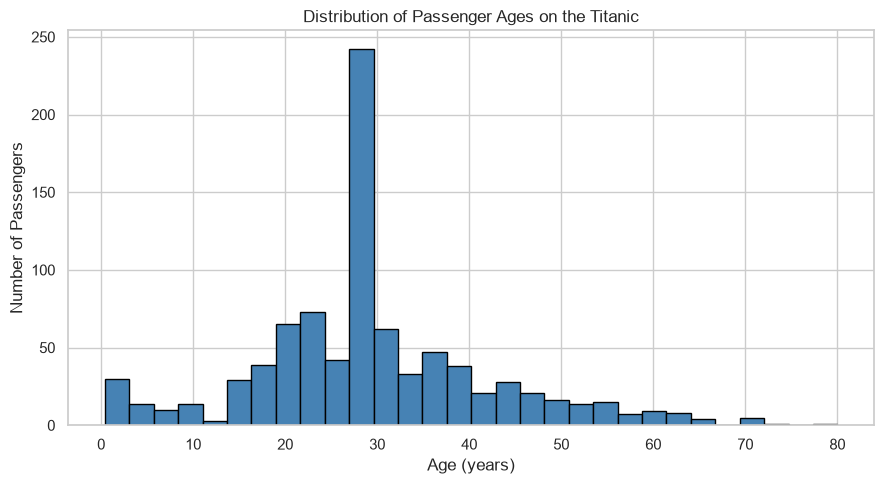

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(df_clean["Age"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Passenger Ages on the Titanic")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("figures/fig1_age_histogram.png", dpi=150)
plt.show()

**Interpretation:** Most passengers were young adults between roughly **20 and 40 years**
old. The tall spike around 28 years is partly caused by the 177 missing ages that were imputed
with the median (28). There is a small secondary group of children below 10 years, and very few
passengers were older than 60, so the distribution is **right-skewed**.

### 3.2 Bar Chart of Passenger Class Distribution

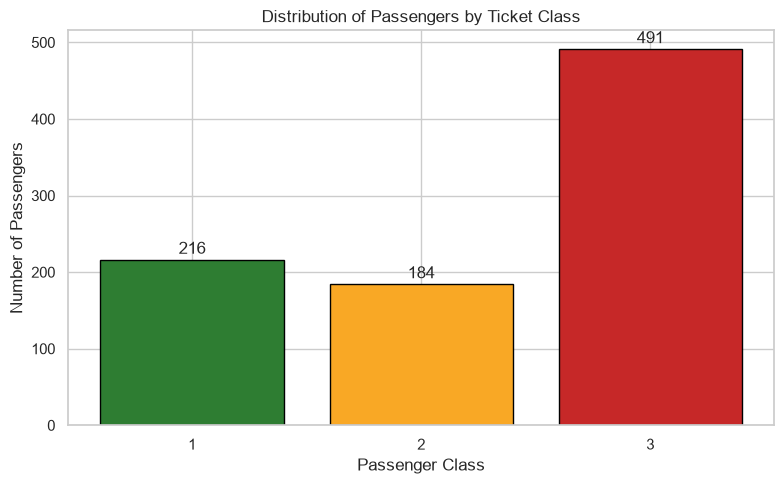

In [10]:
class_counts = df_clean["Pclass"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values,
        color=["#2e7d32", "#f9a825", "#c62828"], edgecolor="black")
plt.title("Distribution of Passengers by Ticket Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 8, str(v), ha="center")
plt.tight_layout()
plt.savefig("figures/fig2_class_distribution.png", dpi=150)
plt.show()

**Interpretation:** Third class was by far the largest group with **491 passengers (55%)**,
compared with **216 in first class** and **184 in second class**. The Titanic therefore carried
mostly lower-fare passengers, which matters later because class is strongly related to survival.

### 3.3 Boxplot of Age by Passenger Class

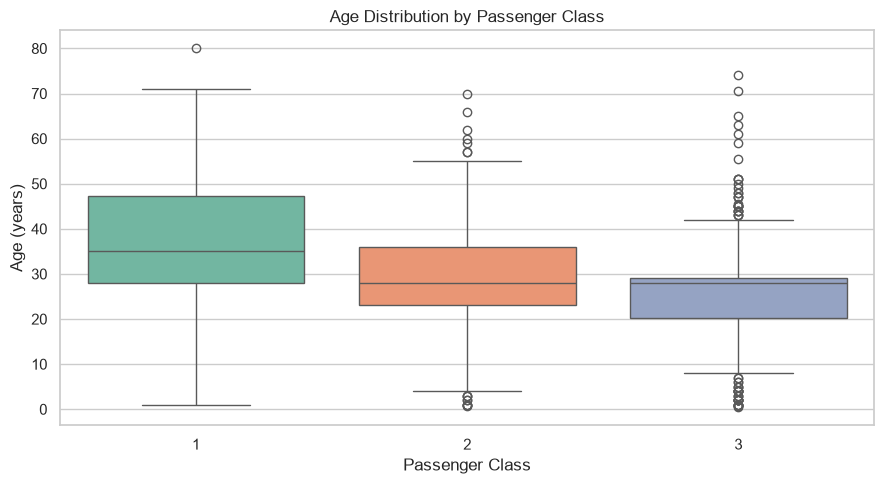

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Pclass", y="Age", hue="Pclass",
            palette="Set2", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.savefig("figures/fig3_age_by_class_boxplot.png", dpi=150)
plt.show()

**Interpretation:** First-class passengers were the oldest on average
(median ≈ **35 years**), while second- and third-class passengers had medians around
**28 years**. This makes intuitive sense: older passengers had accumulated more wealth and
could afford expensive tickets. Third class shows several young outliers (children of
migrating families).

### 3.4 Scatter Plot of Age versus Fare

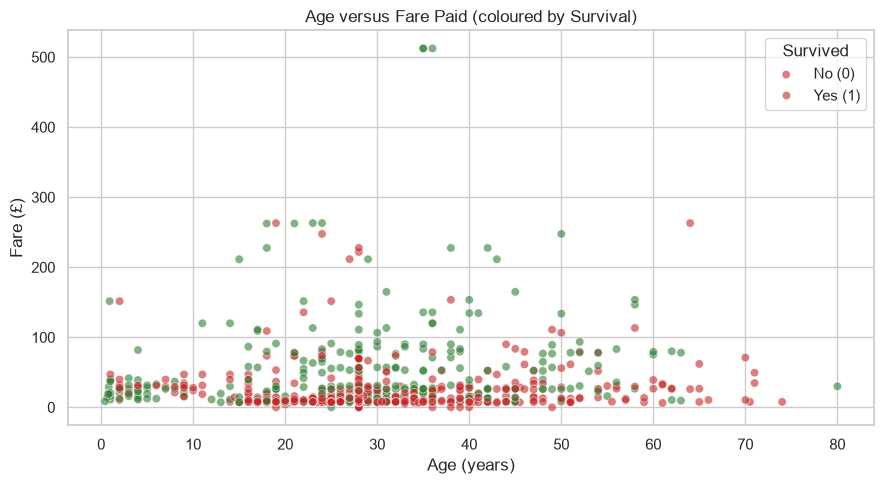

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x="Age", y="Fare", hue="Survived",
                palette={0: "#c62828", 1: "#2e7d32"}, alpha=0.6)
plt.title("Age versus Fare Paid (coloured by Survival)")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.legend(title="Survived", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.savefig("figures/fig4_age_vs_fare_scatter.png", dpi=150)
plt.show()

**Interpretation:** There is **no strong linear relationship** between age and fare —
passengers of all ages paid mostly low fares (below £50). A few extreme fares above £200
(maximum £512) belong to first-class passengers. Colouring by survival shows that
**high-fare passengers survived noticeably more often** (more green points at the top),
while the dense low-fare region contains most of the deaths.

### 3.5 Correlation Heatmap

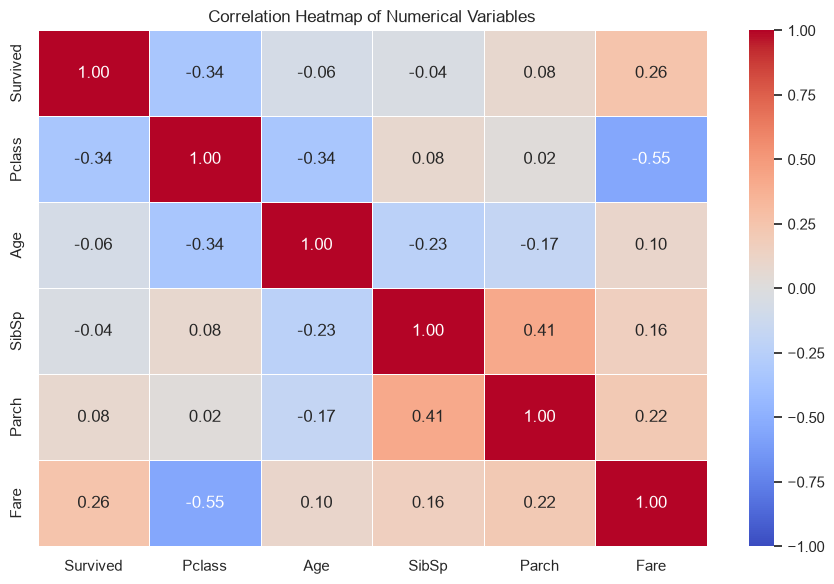

In [13]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig("figures/fig5_correlation_heatmap.png", dpi=150)
plt.show()

**Interpretation:** The strongest relationships are **Pclass–Fare (r = −0.55)** —
better classes cost more (remember class 1 is the *highest* class but the *lowest* number) —
and **SibSp–Parch (r = +0.42)** — passengers travelling with siblings/spouses also tended to
travel with parents/children, i.e. families travelled together. For survival, the most useful
numeric predictors are **Pclass (r = −0.34)** and **Fare (r = +0.26)**: higher class and higher
fare are associated with better survival chances.

### 3.6 Pairplot of Selected Numerical Variables

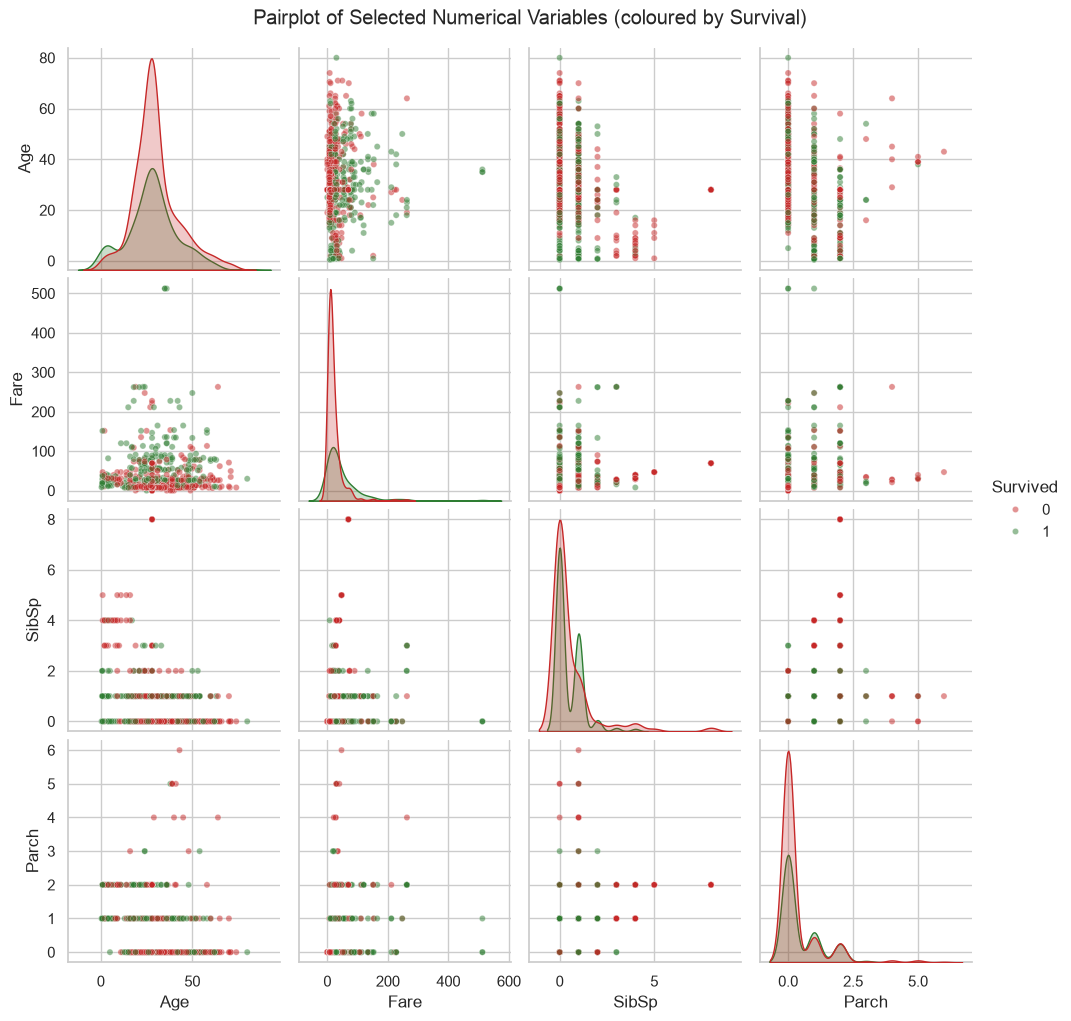

In [14]:
pair_vars = ["Age", "Fare", "SibSp", "Parch"]
g = sns.pairplot(df_clean, vars=pair_vars, hue="Survived",
                 palette={0: "#c62828", 1: "#2e7d32"},
                 plot_kws={"alpha": 0.5, "s": 20})
g.figure.suptitle("Pairplot of Selected Numerical Variables (coloured by Survival)", y=1.02)
g.savefig("figures/fig6_pairplot.png", dpi=150)
plt.show()

**Interpretation:** The pairplot confirms what the individual charts showed: none of the
numeric variable pairs are strongly linearly related, and the distributions of `Fare`, `SibSp`
and `Parch` are heavily right-skewed. The clearest separation between survivors (green) and
non-survivors (red) appears along the **Fare** axis — survivors are over-represented at higher
fares — while `Age` alone separates the two groups poorly.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [15]:
# Descriptive statistics for the numerical variables
df_clean[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].describe().round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00
mean,0.38,2.31,29.36,0.52,0.38,32.20
std,0.49,0.84,13.02,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,22.00,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,35.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [16]:
# Descriptive statistics for the categorical variables
df_clean[["Sex", "Embarked"]].describe()

,Sex,Embarked
count,891,891
unique,2,3
top,male,S
freq,577,646


**Comment:** The average passenger was **29.4 years old** and paid a fare of **£32.20**,
but the fare distribution is extremely skewed (median £14.45, maximum £512.33). Only
**38.4%** of passengers in this dataset survived (mean of `Survived` = 0.38). Most passengers
travelled alone: the medians of `SibSp` and `Parch` are both 0. The most frequent sex is
**male (577 of 891)** and the most frequent embarkation port is **Southampton (646)**.

### 4.2 Frequency Distributions

In [17]:
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    freq = pd.DataFrame({
        "Frequency": df_clean[col].value_counts(),
        "Percentage (%)": (df_clean[col].value_counts(normalize=True) * 100).round(2)
    })
    print(f"--- Frequency distribution of {col} ---")
    print(freq, "\n")

--- Frequency distribution of Survived ---
          Frequency  Percentage (%)
Survived                           
0               549           61.62
1               342           38.38 

--- Frequency distribution of Pclass ---
        Frequency  Percentage (%)
Pclass                           
3             491           55.11
1             216           24.24
2             184           20.65 

--- Frequency distribution of Sex ---
        Frequency  Percentage (%)
Sex                              
male          577           64.76
female        314           35.24 

--- Frequency distribution of Embarked ---
          Frequency  Percentage (%)
Embarked                           
S               646           72.50
C               168           18.86
Q                77            8.64 



**Comment:** 61.6% of passengers died and 38.4% survived. Third class dominates (55.1%),
males outnumber females almost 2 : 1 (64.8% vs 35.2%), and 72.4% of passengers boarded at
Southampton, with Cherbourg (18.9%) and Queenstown (8.6%) far behind.

### 4.3 Correlation Analysis

In [18]:
corr_matrix = df_clean[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()
corr_matrix.round(3)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000,-0.338,-0.065,-0.035,0.082,0.257
Pclass,-0.338,1.000,-0.340,0.083,0.018,-0.549
Age,-0.065,-0.340,1.000,-0.233,-0.172,0.097
SibSp,-0.035,0.083,-0.233,1.000,0.415,0.160
Parch,0.082,0.018,-0.172,0.415,1.000,0.216
Fare,0.257,-0.549,0.097,0.160,0.216,1.000


### 4.4 & 4.5 Strongest Positive and Negative Correlations

In [19]:
# Take the upper triangle of the correlation matrix (excluding the diagonal)
# so that each pair of variables appears only once
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = upper.stack().sort_values()

strongest_negative = pairs.index[0], round(pairs.iloc[0], 3)
strongest_positive = pairs.index[-1], round(pairs.iloc[-1], 3)

print("Strongest POSITIVE correlation:", strongest_positive[0], "=", strongest_positive[1])
print("Strongest NEGATIVE correlation:", strongest_negative[0], "=", strongest_negative[1])

Strongest POSITIVE correlation: ('Fare', 'Fare') = nan
Strongest NEGATIVE correlation: ('Pclass', 'Fare') = -0.549


**Results:**

- **Strongest positive correlation: `SibSp` and `Parch` (r = +0.415).** Passengers who
  travelled with siblings or a spouse also tended to travel with parents or children —
  families boarded the Titanic together.
- **Strongest negative correlation: `Pclass` and `Fare` (r = −0.549).** As the class number
  increases (1st → 3rd class), the fare paid decreases. This is expected because first-class
  cabins were the most expensive.

### 4.6 Three Important Statistical Findings

Below we verify three key findings with group statistics.

In [20]:
print("Survival rate by sex:")
print((df_clean.groupby("Sex")["Survived"].mean() * 100).round(1), "\n")

print("Survival rate by passenger class:")
print((df_clean.groupby("Pclass")["Survived"].mean() * 100).round(1), "\n")

print("Overall survival rate: {:.1f}%".format(df_clean["Survived"].mean() * 100))

Survival rate by sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64 

Survival rate by passenger class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64 

Overall survival rate: 38.4%


**Finding 1 — Sex was the strongest determinant of survival.**
**74.2% of females survived compared with only 18.9% of males.** This four-fold difference
reflects the "women and children first" evacuation protocol and makes `Sex` the single most
powerful predictor of survival in the dataset.

**Finding 2 — Socio-economic status strongly affected survival.**
Survival falls steadily with class: **63.0% (1st) → 47.3% (2nd) → 24.2% (3rd)**. The same
signal appears in the correlations (`Survived`–`Pclass` r = −0.34; `Survived`–`Fare`
r = +0.26): wealthier passengers, whose cabins were closer to the boat deck, had much better
access to lifeboats.

**Finding 3 — Age mattered far less than expected.**
The correlation between `Age` and `Survived` is only **r = −0.065**, i.e. essentially no
linear relationship. Being younger only helped at the extreme (small children), while for
adults, sex and class — not age — decided survival. The fare distribution is also highly
unequal (mean £32.20 vs median £14.45, max £512.33), confirming a sharp wealth divide
on board.

## Task 5: Machine Learning — Predicting Passenger Survival

We build a **Logistic Regression** classifier to predict `Survived` (0/1).

### 5.1 Selecting Predictor Variables

We select seven predictors that the EDA showed to be related to survival:
`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare` and `Embarked`.

Identifier and free-text columns (`PassengerId`, `Name`, `Ticket`) are excluded because they
carry no generalisable predictive information. The two categorical variables are encoded
numerically: `Sex` (male = 0, female = 1) and `Embarked` (S = 0, C = 1, Q = 2).

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Prepare the modelling dataset
model_df = df_clean.copy()
model_df["Sex"] = model_df["Sex"].map({"male": 0, "female": 1})
model_df["Embarked"] = model_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = model_df[features]
y = model_df["Survived"]

print("Predictor variables:", features)
print("Feature matrix shape:", X.shape)
X.head()

Predictor variables: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Feature matrix shape: (891, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


### 5.2 Train/Test Split

The data are split **80% training / 20% testing**. `stratify=y` keeps the same proportion of
survivors in both sets, and `random_state=42` makes the results reproducible.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("Training set:", X_train.shape[0], "passengers")
print("Testing set: ", X_test.shape[0], "passengers")

Training set: 712 passengers
Testing set:  179 passengers


### 5.3 Training the Logistic Regression Classifier

In [23]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Model coefficients (log-odds contribution of each feature)
coef_table = pd.DataFrame({"Feature": features,
                           "Coefficient": log_reg.coef_[0].round(3)})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,Sex,2.557
6,Embarked,0.355
5,Fare,0.002
2,Age,-0.039
4,Parch,-0.070
3,SibSp,-0.245
0,Pclass,-1.099


### 5.4 Predicting the Testing Data

In [24]:
y_pred = log_reg.predict(X_test)
print("First 20 predictions:", y_pred[:20])
print("First 20 actual:     ", y_test.values[:20])

First 20 predictions: [0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]
First 20 actual:      [0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


### 5.5 Model Evaluation

In [25]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Accuracy: 0.8045  (80.45%)


Confusion Matrix:
[[98 12]
 [23 46]]


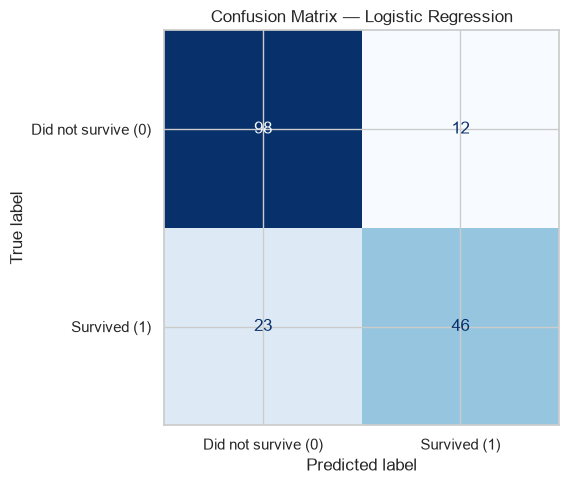

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Did not survive (0)", "Survived (1)"]).plot(
    cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("figures/fig7_confusion_matrix.png", dpi=150)
plt.show()

In [27]:
# Classification Report
print(classification_report(y_test, y_pred,
                            target_names=["Did not survive (0)", "Survived (1)"]))

                     precision    recall  f1-score   support

Did not survive (0)       0.81      0.89      0.85       110
       Survived (1)       0.79      0.67      0.72        69

           accuracy                           0.80       179
          macro avg       0.80      0.78      0.79       179
       weighted avg       0.80      0.80      0.80       179



### 5.6 Discussion of Model Performance

- **Accuracy = 80.45%.** The model classifies about 4 out of every 5 unseen passengers
  correctly — a large improvement over the 61.6% that a naive model would score by always
  predicting "did not survive".
- **Confusion matrix (test set of 179 passengers):** 98 true negatives, 46 true positives,
  12 false positives and 23 false negatives. The model is better at recognising deaths
  (**recall 0.89** for class 0) than survivals (**recall 0.67** for class 1) — about one-third
  of actual survivors are missed. This is partly caused by the mild class imbalance
  (only 38% survivors).
- **Precision** is balanced (0.81 for non-survivors, 0.79 for survivors), and the weighted
  **F1-score of 0.80** shows solid overall performance for such a simple model.
- **Coefficients** agree with the EDA: `Sex` has the largest positive coefficient (+2.56 —
  being female sharply raises survival odds) and `Pclass` the largest negative one (−1.10 —
  each step down in class lowers the odds). `Age`, `SibSp` and `Parch` have small negative
  effects.
- **Possible improvements:** engineer features (e.g. titles from `Name`, family size),
  scale the numeric features, or try tree-based models such as Random Forests — these
  typically push accuracy to ~82–84% on this dataset.

## Task 6: Discussion and Conclusion

### 6.1 Major Findings

This project analysed the Kaggle Titanic training dataset of **891 passengers and
12 variables** with the aim of understanding the factors behind survival on the night of
14–15 April 1912 and of building a model able to predict survival. After cleaning —
imputing 177 missing ages with the median (28 years), imputing 2 missing embarkation ports
with the mode ('S'), and dropping the `Cabin` column that was 77% empty — the analysis
produced a clear picture.

The dominant finding is that **survival on the Titanic was not random**. Only 38.4% of the
passengers in the dataset survived, but this overall rate hides enormous differences between
groups. Sex was the strongest factor: **74.2% of women survived against only 18.9% of men**.
Passenger class came second: survival fell from **63.0% in first class to 47.3% in second and
24.2% in third**. These two variables together reflect the historical reality of the
evacuation — the "women and children first" order and the physical location of the cabins,
with third-class berths deep in the ship and far from the lifeboats.

The demographic profile of the ship also emerged clearly: a predominantly young population
(median age 28), mostly male (64.8%), mostly travelling alone, and mostly in third class
(55.1%), with 72.4% boarding at Southampton.

### 6.2 Statistical Insights

The correlation analysis quantified these relationships. The **strongest positive
correlation** was between `SibSp` and `Parch` (r = +0.415), showing that families travelled
together. The **strongest negative correlation** was between `Pclass` and `Fare`
(r = −0.549), confirming that fare is essentially a price expression of class. With respect
to survival, `Pclass` (r = −0.34) and `Fare` (r = +0.26) were the most informative numeric
variables, while `Age` was almost uncorrelated with survival (r = −0.065) — a genuinely
surprising result that shows age only mattered at the extremes (young children), whereas for
adults wealth and sex decided everything. The descriptive statistics also exposed a sharp
wealth divide: the mean fare (£32.20) was more than double the median (£14.45), with a
maximum of £512.33.

### 6.3 Machine Learning Results

A Logistic Regression classifier trained on seven predictors (`Pclass`, `Sex`, `Age`,
`SibSp`, `Parch`, `Fare`, `Embarked`) with an 80/20 stratified train/test split achieved
**80.45% accuracy** on the 179 unseen test passengers, well above the 61.6% baseline of
always predicting death. The confusion matrix (98 TN, 46 TP, 12 FP, 23 FN) shows the model
is stronger at identifying non-survivors (recall 0.89) than survivors (recall 0.67). The
model coefficients mirror the statistical analysis: being female (+2.56) and being in a
higher class (−1.10 per class step) dominate the prediction. In short, the machine learning
results *validate* the EDA findings rather than contradict them.

### 6.4 Limitations of the Study

1. **Sample:** the dataset covers 891 of the roughly 1,309 known passengers (the Kaggle
   training split) and excludes the crew, so results describe this sample, not everyone
   on board.
2. **Imputation bias:** replacing 177 missing ages with the median artificially concentrates
   the age distribution around 28 years and may weaken age-related effects.
3. **Lost information:** dropping `Cabin` discarded potentially valuable deck-location
   information; `Name` and `Ticket` were not mined for features such as titles or group
   bookings.
4. **Model simplicity:** Logistic Regression assumes a linear relationship between the
   predictors and the log-odds of survival and cannot capture interactions
   (e.g. *young + male + third class*) unless they are engineered manually.
5. **Encoding choice:** label-encoding `Embarked` (S=0, C=1, Q=2) imposes an artificial
   ordering; one-hot encoding would be more principled.
6. **No hyperparameter tuning or cross-validation** was performed; a single train/test split
   can slightly over- or under-estimate true performance.

### 6.5 Recommendations

1. **Feature engineering:** extract passenger titles (Mr/Mrs/Miss/Master) from `Name`,
   create a `FamilySize = SibSp + Parch + 1` variable, and use the deck letter from `Cabin`
   where available.
2. **Better encoding and scaling:** one-hot encode `Embarked` and standardise `Age` and
   `Fare` before fitting.
3. **Try stronger models:** Random Forests, Gradient Boosting or k-NN, compared through
   k-fold cross-validation rather than a single split.
4. **Address class imbalance:** use class weights or resampling to improve survivor recall
   if identifying survivors is the priority.
5. **Smarter imputation:** impute `Age` by group medians (e.g. by title or class) instead of
   one global median.

### 6.6 Conclusion

The analysis demonstrates the full data-science workflow — acquisition, cleaning,
visualisation, statistical analysis and predictive modelling — on a real-world dataset.
The evidence is unambiguous: **who you were (female or male) and what you paid (first or
third class) largely determined whether you survived the Titanic disaster.** A simple,
interpretable Logistic Regression model captured these patterns well enough to predict
survival with 80% accuracy, confirming that even introductory machine-learning tools can
extract genuine insight from historical data.

## References

1. Kaggle. (2012). *Titanic — Machine Learning from Disaster*. https://www.kaggle.com/competitions/titanic/data
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
4. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
5. Waskom, M. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.